In [3]:
import numpy as np
import matplotlib.pyplot as plt
from repeaters_NV import RepeaterParams
import seaborn as sns
from matplotlib.ticker import FormatStrFormatter
import pandas as pd

sns.set_theme(style="white", rc={
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "xtick.bottom": True,
    "ytick.left": True,
    "figure.autolayout": True
})

def entanglement_rate_vs_distance(params, distances):
    """
    Elementary entanglement generation rate [pairs/s]
    as a function of elementary link distance.
    """

    distances = np.asarray(distances)

    # Each photon travels half the elementary link
    half_dist = distances / 2

    P_click = (
        params.p_det
        * params.eta_c
        * params.eta_M
        * 10 ** (-params.alpha * half_dist / 10)
    )

    P_click = 1-(1-P_click)**params.M

    # Probability both photons arrive and a Bell-state measurement succeeds
    P_both = 0.5 * P_click**2

    # Expected rate
    rate = params.nu * P_both

    return rate

In [2]:
params = RepeaterParams()
params.p_det     = 0.95
params.alpha     = 0.18
params.V         = 0.95
params.nu        = 167e3
params.R_dark    = 100
params.delta_det = 100e-12
params.eta_c     = 0.8
params.P_BSM     = 0.9993
params.eta_M     = 0.46
params.T_coh     = 0.05
params.M = 1


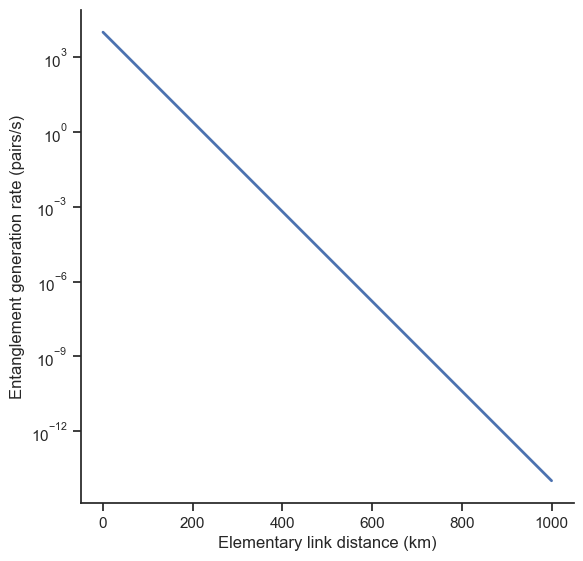

In [4]:
distances = np.linspace(0, 1000, 500)

rates = entanglement_rate_vs_distance(params, distances)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(distances, rates, lw=2)
ax.set_yscale('log')
ax.set_xlabel("Elementary link distance (km)")
ax.set_ylabel("Entanglement generation rate (pairs/s)")
ax.set_box_aspect(1) # Forces the plot area to be perfectly square
# Enable minor tick labels and set formatter
plt.tick_params(axis='y', which='minor')

plt.savefig('tests/prunning.png', bbox_inches='tight')
plt.show()

In [8]:
import numpy as np

def calculate_d_max(params, k_min, multiplexing_type=None, M=20, distillation_level=1):
    """
    Calculates the exact physical pruning distance (d_max) for a given k_min.
    """
    # 1. Base constants
    nu = params.nu
    p_det = params.p_det
    eta_c = params.eta_c
    eta_M = params.eta_M
    alpha = params.alpha

    # 2. Target probability required to hit k_min
    target_P_both_raw = k_min / nu

    if target_P_both_raw >= 1.0:
        return 0.0 # Impossible to reach this rate

    # 3. Reverse the multiplexing to find the required single-shot P_both_succ
    if multiplexing_type == 'accumulated':
        req_P_both_succ = 1 - (1 - target_P_both_raw)**(1/M)
    elif multiplexing_type == 'single_burst':
        from scipy.optimize import root_scalar
        from scipy.stats import binom
        m_required = 2 ** distillation_level

        def obj(p):
            return (1 - binom.cdf(m_required - 1, M, p)) - target_P_both_raw

        res = root_scalar(obj, bracket=[0, 1])
        req_P_both_succ = res.root
    else:
        req_P_both_succ = target_P_both_raw

    # 4. Reverse the optical math to find distance
    constant_factor = (p_det * eta_c * eta_M)**2
    inner_log = (2 * req_P_both_succ) / constant_factor

    if inner_log >= 1.0:
        return 0.0 # Requires distance <= 0

    d_max = -(10 / alpha) * np.log10(inner_log)
    return d_max

In [9]:
calculate_d_max(params, 100)

np.float64(111.60162907824072)

In [10]:
calculate_d_max(params, 1000, multiplexing_type='accumulated')

np.float64(128.256721567478)

Saved percolation_no_mux.png and percolation_mux20.png


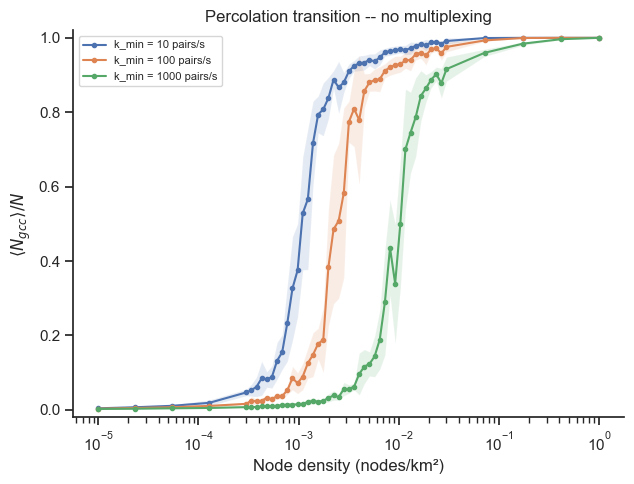

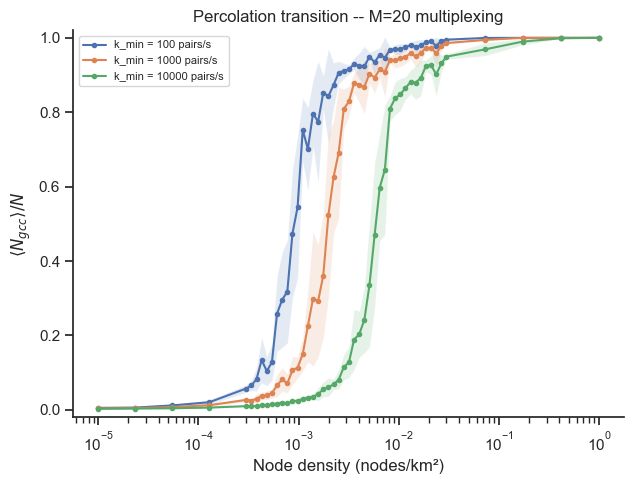

In [22]:


INPUT_CSV = "percolation_results.csv"

df = pd.read_csv(INPUT_CSV)

# mean +/- std over repetitions, per (mux_type, k_min, density)
summary = (
    df.groupby(["mux_type", "k_min", "density"])["giant_fraction"]
      .agg(["mean", "std", "count"])
      .reset_index()
)


def plot_case(ax, mux_label, title):
    sub = summary[summary["mux_type"] == mux_label]
    for k_min, grp in sub.groupby("k_min"):
        grp = grp.sort_values("density")
        ax.plot(grp["density"], grp["mean"], marker="o", markersize=3,
                label=f"k_min = {k_min:g} pairs/s")
        ax.fill_between(
            grp["density"],
            grp["mean"] - grp["std"],
            grp["mean"] + grp["std"],
            alpha=0.15,
        )
    ax.set_xscale("log")
    ax.set_xlabel("Node density (nodes/km²)")
    ax.set_ylabel(r"$\langle N_{gcc} \rangle / N$")
    ax.set_ylim(-0.02, 1.02)
    ax.set_title(title)
    ax.legend(fontsize=8)


fig1, ax1 = plt.subplots(figsize=(6.5, 5))
plot_case(ax1, "no_mux", "Percolation transition -- no multiplexing")
fig1.tight_layout()
fig1.savefig("percolation_no_mux.png", dpi=150)

fig2, ax2 = plt.subplots(figsize=(6.5, 5))
plot_case(ax2, "mux20", "Percolation transition -- M=20 multiplexing")
fig2.tight_layout()
fig2.savefig("percolation_mux20.png", dpi=150)

print("Saved percolation_no_mux.png and percolation_mux20.png")

In [7]:


INPUT_CSV = "percolation_results.csv"
OUTPUT_PNG = "percolation_susceptibility.png"

# Zoom window around the transition for the right-hand panel.
# Adjust these once you see where your transition actually sits.
ZOOM_RHO_MIN = 1e-3
ZOOM_RHO_MAX = 5e-3

MUX_KMIN_STYLES = {
    # (mux_type, k_min) -> style dict; filled in dynamically below if not listed
}

MIDDLE_KMIN = {"no_mux": 1e2, "mux20": 1e3}
RHO_C_GUESS = {
    ("no_mux", 1e2): 2.225e-3,
    ("mux20", 1e3): 1.95e-3,
}
def compute_susceptibility(df):
    """
    Returns a DataFrame with one row per (mux_type, k_min, density):
    mean_N_gcc, var_N_gcc, chi, n_reps_used.
    """
    grouped = (
        df.groupby(["mux_type", "k_min", "density"])["N_gcc"]
        .agg(mean_N_gcc="mean", var_N_gcc=lambda s: s.var(ddof=0), n_reps_used="count")
        .reset_index()
    )
    grouped["chi"] = grouped["var_N_gcc"] / grouped["mean_N_gcc"]
    return grouped


def plot_susceptibility(chi_df, giant_df):
    combos = chi_df[["mux_type", "k_min"]].drop_duplicates().values.tolist()
    cmap = plt.get_cmap("tab10")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    for i, (mux_type, k_min) in enumerate(combos):
        style = MUX_KMIN_STYLES.get((mux_type, k_min), dict(color=cmap(i % 10), marker="o"))
        label = f"{mux_type}, k_min={k_min:g}"

        sub = chi_df[(chi_df["mux_type"] == mux_type) & (chi_df["k_min"] == k_min)].sort_values("density")
        gsub = giant_df[(giant_df["mux_type"] == mux_type) & (giant_df["k_min"] == k_min)].sort_values("density")

        # Left panel: full-range giant-component fraction for context (fig 1a analog)
        axes[0].plot(gsub["density"], gsub["mean_frac"], label=label, **style)

        # Right panel: susceptibility, zoomed near the transition (fig 1b analog)
        zsub = sub[(sub["density"] >= ZOOM_RHO_MIN) & (sub["density"] <= ZOOM_RHO_MAX)]
        axes[1].plot(zsub["density"], zsub["chi"], label=label, **style)
        rho_c = RHO_C_GUESS.get((mux_type, k_min))
        if rho_c is not None:
            line_color = style.get("color", cmap(i % 10))
            axes[0].axvline(rho_c, color=line_color, linestyle="--", alpha=0.7, linewidth=1.5)
            axes[1].axvline(rho_c, color=line_color, linestyle="--", alpha=0.7, linewidth=1.5)

    axes[0].set_xscale("log")
    axes[0].set_xlabel(r"$\rho$ [km$^{-2}$]")
    axes[0].set_ylabel(r"$\langle N_{gcc}\rangle / N$")
    axes[0].set_title("(a) Connectivity")
    axes[0].grid(alpha=0.3)
    axes[0].legend(fontsize=8)

    axes[1].set_xscale("log")
    axes[1].set_xlabel(r"$\rho$ [km$^{-2}$]")
    axes[1].set_ylabel(r"$\chi$")
    axes[1].set_title("(b) Susceptibility (zoomed near transition)")
    axes[1].grid(alpha=0.3)
    axes[1].legend(fontsize=8)

    fig.tight_layout()
    fig.savefig(OUTPUT_PNG, dpi=150)
    plt.close(fig)
    print(f"Saved {OUTPUT_PNG}")


if __name__ == "__main__":
    df = pd.read_csv(INPUT_CSV)

    # mean giant fraction per (mux_type, k_min, density), for the context panel
    giant_df = (
        df.groupby(["mux_type", "k_min", "density"])["giant_fraction"]
        .mean()
        .reset_index()
        .rename(columns={"giant_fraction": "mean_frac"})
    )

    chi_df = compute_susceptibility(df)
    keep_mask = chi_df.apply(lambda r: MIDDLE_KMIN.get(r["mux_type"]) == r["k_min"], axis=1)
    chi_df = chi_df[keep_mask]
    giant_keep_mask = giant_df.apply(lambda r: MIDDLE_KMIN.get(r["mux_type"]) == r["k_min"], axis=1)
    giant_df = giant_df[giant_keep_mask]

    # Warn if rep counts look too low to trust chi
    min_reps = chi_df["n_reps_used"].min()
    if min_reps < 20:
        print(f"WARNING: only {min_reps} reps behind some chi estimates -- expect a noisy peak. "
              f"Consider rerunning percolation_study.py with more N_REPS and denser "
              f"sampling near rho_c for a cleaner curve.")

    chi_df.to_csv("percolation_susceptibility.csv", index=False)
    print(f"Saved per-(mux,k_min,density) chi values to percolation_susceptibility.csv")

    plot_susceptibility(chi_df, giant_df)

Saved per-(mux,k_min,density) chi values to percolation_susceptibility.csv
Saved percolation_susceptibility.png


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

INPUT_CSV = "percolation_results_peak_focus.csv"
OUTPUT_PNG = "percolation_susceptibility_thesis_style.png"

# Zoom window around the transition for the right-hand panel
ZOOM_RHO_MIN = 1e-3
ZOOM_RHO_MAX = 5e-3

# Only plot the middle k_min threshold from each case's list
MIDDLE_KMIN = {
    "no_mux": 1e2,
    "mux20": 1e3,
}

# The colors mapped to your mux types
COLORS = {
    "no_mux": "#ff7f0e", # Orange
    "mux20": "#2ca02c",  # Green
}

# Clean labels for the legend
LABELS = {
    "no_mux": "Sequential",
    "mux20": "Multiplexed (M=20)",
}

# Eyeballed transition guesses for the vertical dotted lines
RHO_C_GUESS = {
    ("no_mux", 1e2): 2.0e-3,
    ("mux20", 1e3): 1.8e-3,
}

def compute_susceptibility(df, n_boot=200):
    """
    Returns a DataFrame with one row per (mux_type, k_min, density)
    Calculates chi and uses a bootstrap method to find the standard deviation of chi for shading.
    """
    grouped = df.groupby(["mux_type", "k_min", "density"])["N_gcc"]
    records = []

    for (mux, k, rho), group in grouped:
        vals = group.values
        mean_val = vals.mean()
        var_val = vals.var(ddof=0)
        chi = var_val / mean_val if mean_val > 0 else 0

        # Bootstrap error calculation for chi to create the shading
        if len(vals) > 1:
            boot_chis = []
            for _ in range(n_boot):
                b_vals = np.random.choice(vals, size=len(vals), replace=True)
                b_mean = b_vals.mean()
                b_chi = b_vals.var(ddof=0) / b_mean if b_mean > 0 else 0
                boot_chis.append(b_chi)
            chi_std = np.std(boot_chis)
        else:
            chi_std = 0

        records.append({
            "mux_type": mux,
            "k_min": k,
            "density": rho,
            "n_reps_used": len(vals),
            "mean_N_gcc": mean_val,
            "var_N_gcc": var_val,
            "chi": chi,
            "chi_std": chi_std
        })

    return pd.DataFrame(records)


def plot_susceptibility(chi_df, giant_df):
    combos = chi_df[["mux_type", "k_min"]].drop_duplicates().values.tolist()

    # Apply the clean thesis style
    sns.set_theme(style="ticks")
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    for i, (mux_type, k_min) in enumerate(combos):
        color = COLORS.get(mux_type, "#333333")
        label = f"{LABELS.get(mux_type, mux_type)} ($k_{{\\rm min}}={k_min:g}$)"

        sub = chi_df[(chi_df["mux_type"] == mux_type) & (chi_df["k_min"] == k_min)].sort_values("density")
        gsub = giant_df[(giant_df["mux_type"] == mux_type) & (giant_df["k_min"] == k_min)].sort_values("density")

        # --- Left panel: Connectivity with shading ---
        axes[0].plot(gsub["density"], gsub["mean_frac"], color=color, lw=2, label=label)
        axes[0].fill_between(gsub["density"],
                             gsub["mean_frac"] - gsub["std_frac"],
                             gsub["mean_frac"] + gsub["std_frac"],
                             color=color, alpha=0.2)

        # --- Right panel: Susceptibility WITH bootstrapped shading ---
        zsub = sub[(sub["density"] >= ZOOM_RHO_MIN) & (sub["density"] <= ZOOM_RHO_MAX)]
        axes[1].plot(zsub["density"], zsub["chi"], color=color, lw=2, label=label)
        axes[1].fill_between(zsub["density"],
                             zsub["chi"] - zsub["chi_std"],
                             zsub["chi"] + zsub["chi_std"],
                             color=color, alpha=0.2)

        # Dashed vertical line at the guessed transition density
        rho_c = RHO_C_GUESS.get((mux_type, k_min))
        if rho_c is not None:
            axes[0].axvline(rho_c, color=color, linestyle=":", alpha=0.7, label=f"Estimated $\\rho_c$ ({LABELS.get(mux_type, mux_type)})")
            axes[1].axvline(rho_c, color=color, linestyle=":", alpha=0.7)

    # --- Formatting Left Panel ---
    axes[0].set_xscale("log")
    axes[0].set_xlabel(r"$\rho$ (km$^{-2}$)", fontsize=12)
    axes[0].set_ylabel(r"$\langle N_{\rm gcc}\rangle / N$", fontsize=12)
    axes[0].grid(False)
    axes[0].set_box_aspect(1)
    axes[0].text(-0.15, 1.05, '(a)', transform=axes[0].transAxes, fontsize=14, fontweight='bold', va='top')
    axes[0].legend(fontsize=9, loc='upper left', frameon=False)

    # --- Formatting Right Panel ---
    axes[1].set_xscale("log")
    axes[1].set_xlabel(r"$\rho$ (km$^{-2}$)", fontsize=12)
    axes[1].set_ylabel(r"$\chi$", fontsize=12) # Shortened as requested
    axes[1].grid(False)
    axes[1].set_box_aspect(1)
    axes[1].text(-0.15, 1.05, '(b)', transform=axes[1].transAxes, fontsize=14, fontweight='bold', va='top')

    # Legend moved to upper right to avoid overlapping with the peaks
    axes[1].legend(fontsize=9, loc='upper right', frameon=False)

    sns.despine()
    fig.tight_layout()
    fig.savefig(OUTPUT_PNG, dpi=300, bbox_inches='tight')
    plt.close(fig)
    print(f"Saved {OUTPUT_PNG}")


# --- Main Execution ---
df = pd.read_csv(INPUT_CSV)

# Compute mean AND standard deviation for the giant fraction so we can shade it
giant_df = (
    df.groupby(["mux_type", "k_min", "density"])["giant_fraction"]
    .agg(mean_frac="mean", std_frac="std")
    .reset_index()
)

print("Calculating susceptibility and bootstrapping errors... (this may take a few seconds)")
chi_df = compute_susceptibility(df, n_boot=200)

# Warn if rep counts look too low to trust chi
min_reps = chi_df["n_reps_used"].min()
if min_reps < 20:
    print(f"WARNING: only {min_reps} reps behind some chi estimates -- expect a noisy peak. "
          f"Consider rerunning percolation_study.py with more N_REPS.")

chi_df.to_csv("percolation_susceptibility.csv", index=False)
print(f"Saved per-(mux,k_min,density) chi values to percolation_susceptibility.csv")

# Keep only the middle k_min for each mux case
keep_mask = chi_df.apply(lambda r: MIDDLE_KMIN.get(r["mux_type"]) == r["k_min"], axis=1)
chi_df = chi_df[keep_mask]
giant_keep_mask = giant_df.apply(lambda r: MIDDLE_KMIN.get(r["mux_type"]) == r["k_min"], axis=1)
giant_df = giant_df[giant_keep_mask]

missing = [m for m, k in MIDDLE_KMIN.items() if not ((chi_df["mux_type"] == m) & (chi_df["k_min"] == k)).any()]
if missing:
    print(f"WARNING: no rows found for middle k_min of {missing} -- check MIDDLE_KMIN matches INPUT_CSV.")

plot_susceptibility(chi_df, giant_df)

Calculating susceptibility and bootstrapping errors... (this may take a few seconds)
Saved per-(mux,k_min,density) chi values to percolation_susceptibility.csv
Saved percolation_susceptibility_thesis_style.png


In [19]:


INPUT_CSV = "parameter_results.csv"

METRICS = [
    ("avg_skr",       "Avg. SKR (1/s)",         True),   # (col, ylabel, log_y)
    ("avg_qber",      "Avg. QBER",               False),
    ("avg_fidelity",  "Avg. Fidelity",           False),
    ("avg_ent_rate",  "Avg. Entanglement Rate (1/s)", True),
    ("reachability",  "Reachability",            False),
]

PARAM_LABELS = {
    "P_BSM":    "P_BSM",
    "T_coh":     "T_coh (s)",
    "eta_total": "Total efficiency (eta_M * eta_c)",
    "alpha":     "Fibre loss alpha (dB/km)",
    "V":         "Visibility V",
}

MUX_STYLES = {
    "no_mux": dict(color="tab:blue", marker="o", label="No mux"),
}


def plot_one_parameter(df, param_label, outfile):
    sub = df[df["param"] == param_label]
    n_rows, n_cols = 2, 3
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    axes = axes.flatten()

    for ax, (col, ylabel, log_y) in zip(axes, METRICS):
        for mux_label, style in MUX_STYLES.items():
            mux_sub = sub[sub["mux_type"] == mux_label]
            grouped = (
                mux_sub.groupby("param_value")[col]
                .agg(["mean", "std"])
                .reset_index()
                .sort_values("param_value")
            )
            ax.plot(
                grouped["param_value"], grouped["mean"],
                marker="o", markersize=3, label=style["label"],
            )
            ax.fill_between(
                grouped["param_value"],
                grouped["mean"] - grouped["std"],
                grouped["mean"] + grouped["std"],
                alpha=0.15,
            )
        ax.set_xlabel(PARAM_LABELS.get(param_label, param_label))
        ax.set_ylabel(ylabel)
        if param_label == "T_coh":
            ax.set_xscale("log")
        if log_y:
            ax.set_yscale("log")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    # 5 metrics into a 2x3 grid leaves one empty slot -- hide it rather than
    # leaving a blank plot frame.
    for ax in axes[len(METRICS):]:
        ax.axis("off")

    fig.suptitle(f"Network metrics vs. {PARAM_LABELS.get(param_label, param_label)} "
                 f"(density fixed at 10^0 nodes/km^2)")
    fig.tight_layout()
    fig.savefig(outfile, dpi=150)
    plt.close(fig)
    print(f"Saved {outfile}")


df = pd.read_csv(INPUT_CSV)
for param_label in df["param"].unique():
    outfile = f"parameter_study_{param_label}.png"
    plot_one_parameter(df, param_label, outfile)

Saved parameter_study_P_BSM.png
Saved parameter_study_T_coh.png
Saved parameter_study_eta_total.png
Saved parameter_study_alpha.png
Saved parameter_study_V.png


In [7]:

INPUT_CSV = "density_results.csv"

df = pd.read_csv(INPUT_CSV)

# mean +/- std over repetitions, per (mux_type, density)
METRIC_COLS = ["avg_skr", "avg_qber", "avg_fidelity", "avg_ent_rate", "reachability"]
summary = (
    df.groupby(["mux_type", "density"])[METRIC_COLS]
      .agg(["mean", "std"])
      .reset_index()
)

LABELS = {"no_mux": "No multiplexing", "mux20": "M = 20 multiplexing"}
COLORS = {"no_mux": "tab:blue", "mux20": "tab:orange"}

# Optional: if you know each case's percolation density (from your
# percolation study), set it here to only plot densities at/above it, e.g.
# PERC_DENSITY = {"no_mux": 0.01, "mux20": 0.003}. Leave as None to plot
# the full swept range for both.
PERC_DENSITY = {"no_mux": None, "mux20": None}

# (metric column, ylabel, title, filename prefix, yscale, ylim)
METRICS = [
    ("avg_skr",      "Avg. SKR (bit/s)",              "Secret key rate vs. density",        "skr",       "symlog", None),
    ("avg_qber",     "Avg. QBER",                       "QBER vs. density",                    "qber",      "linear", (0, 0.55)),
    ("avg_fidelity", "Avg. Fidelity",                   "Fidelity vs. density",                "fidelity",  "linear", (0.2, 1.02)),
    ("avg_ent_rate", "Avg. Entanglement Rate (1/s)",    "Entanglement generation rate vs. density", "ent_rate", "symlog", None),
    ("reachability", "Reachability",                    "Reachability vs. density",            "reachability", "linear", (-0.02, 1.02)),
]


def plot_metric_for_mux(metric, ylabel, title, mux_type, yscale, ylim, filename):
    sub = summary[summary["mux_type"] == mux_type].sort_values("density")
    if PERC_DENSITY.get(mux_type) is not None:
        sub = sub[sub["density"] >= PERC_DENSITY[mux_type]]
    if sub.empty:
        print(f"Skipping {filename} -- no data for mux_type={mux_type}")
        return

    fig, ax = plt.subplots(figsize=(6.5, 5))

    x = sub["density"]
    mean = sub[(metric, "mean")]
    std = sub[(metric, "std")].fillna(0.0)

    ax.plot(x, mean, marker="o", markersize=3,
            label=LABELS[mux_type], color=COLORS[mux_type])
    ax.fill_between(x, mean - std, mean + std,
                     alpha=0.15, color=COLORS[mux_type])

    ax.set_xscale("log")
    ax.set_yscale(yscale)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.set_xlabel(r"Node density (nodes/km$^2$)")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{title} -- {LABELS[mux_type]}")
    ax.legend(fontsize=9)
    fig.tight_layout()
    fig.savefig(filename, dpi=150)
    plt.close(fig)
    print(f"Saved {filename}")


for metric, ylabel, title, fname_prefix, yscale, ylim in METRICS:
    for mux_type in ["no_mux", "mux20"]:
        filename = f"{fname_prefix}_vs_density_{mux_type}.png"
        plot_metric_for_mux(metric, ylabel, title, mux_type, yscale, ylim, filename)

    print("Done.")

Saved skr_vs_density_no_mux.png
Saved skr_vs_density_mux20.png
Done.
Saved qber_vs_density_no_mux.png
Saved qber_vs_density_mux20.png
Done.
Saved fidelity_vs_density_no_mux.png
Saved fidelity_vs_density_mux20.png
Done.
Saved ent_rate_vs_density_no_mux.png
Saved ent_rate_vs_density_mux20.png
Done.
Saved reachability_vs_density_no_mux.png
Saved reachability_vs_density_mux20.png
Done.
